In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder

In [5]:
df = pd.read_csv('insurance_claims_clean.csv')
df.head()


,Unnamed: 0,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,insured_sex,insured_education_level,insured_occupation,insured_hobbies,...,police_report_available,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,insured_zip_class,policy_duration_days
0,0,48,OH,250/500,1000,1406.91,MALE,MD,craft-repair,sleeping,...,YES,6510,13020,52080,Saab,92x,2004,Y,46,100
1,1,42,IN,250/500,2000,1197.22,MALE,MD,machine-op-inspct,reading,...,Unknown,780,780,3510,Mercedes,E400,2007,Y,46,3130
2,2,29,OH,100/300,2000,1413.14,FEMALE,PhD,sales,board-games,...,NO,7700,3850,23100,Dodge,RAM,2007,N,43,5282
3,3,41,IL,250/500,2000,1415.74,FEMALE,PhD,armed-forces,board-games,...,NO,6340,6340,50720,Chevrolet,Tahoe,2014,Y,60,8996
4,4,44,IL,500/1000,1000,1583.91,MALE,Associate,sales,board-games,...,NO,1300,650,4550,Accura,RSX,2009,N,61,256


In [6]:
print(df.columns)
df.dtypes

Index(['Unnamed: 0', 'age', 'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'capital_gains', 'capital_loss', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'incident_city', 'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'injury_claim',
       'property_claim', 'vehicle_claim', 'auto_make', 'auto_model',
       'auto_year', 'fraud_reported', 'insured_zip_class',
       'policy_duration_days'],
      dtype='object')


Unnamed: 0                       int64
age                              int64
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital_gains                    int64
capital_loss                     int64
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               object
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
property_damage                 object
bodily_injuries                  int64
witnesses                        int64
police_report_available  

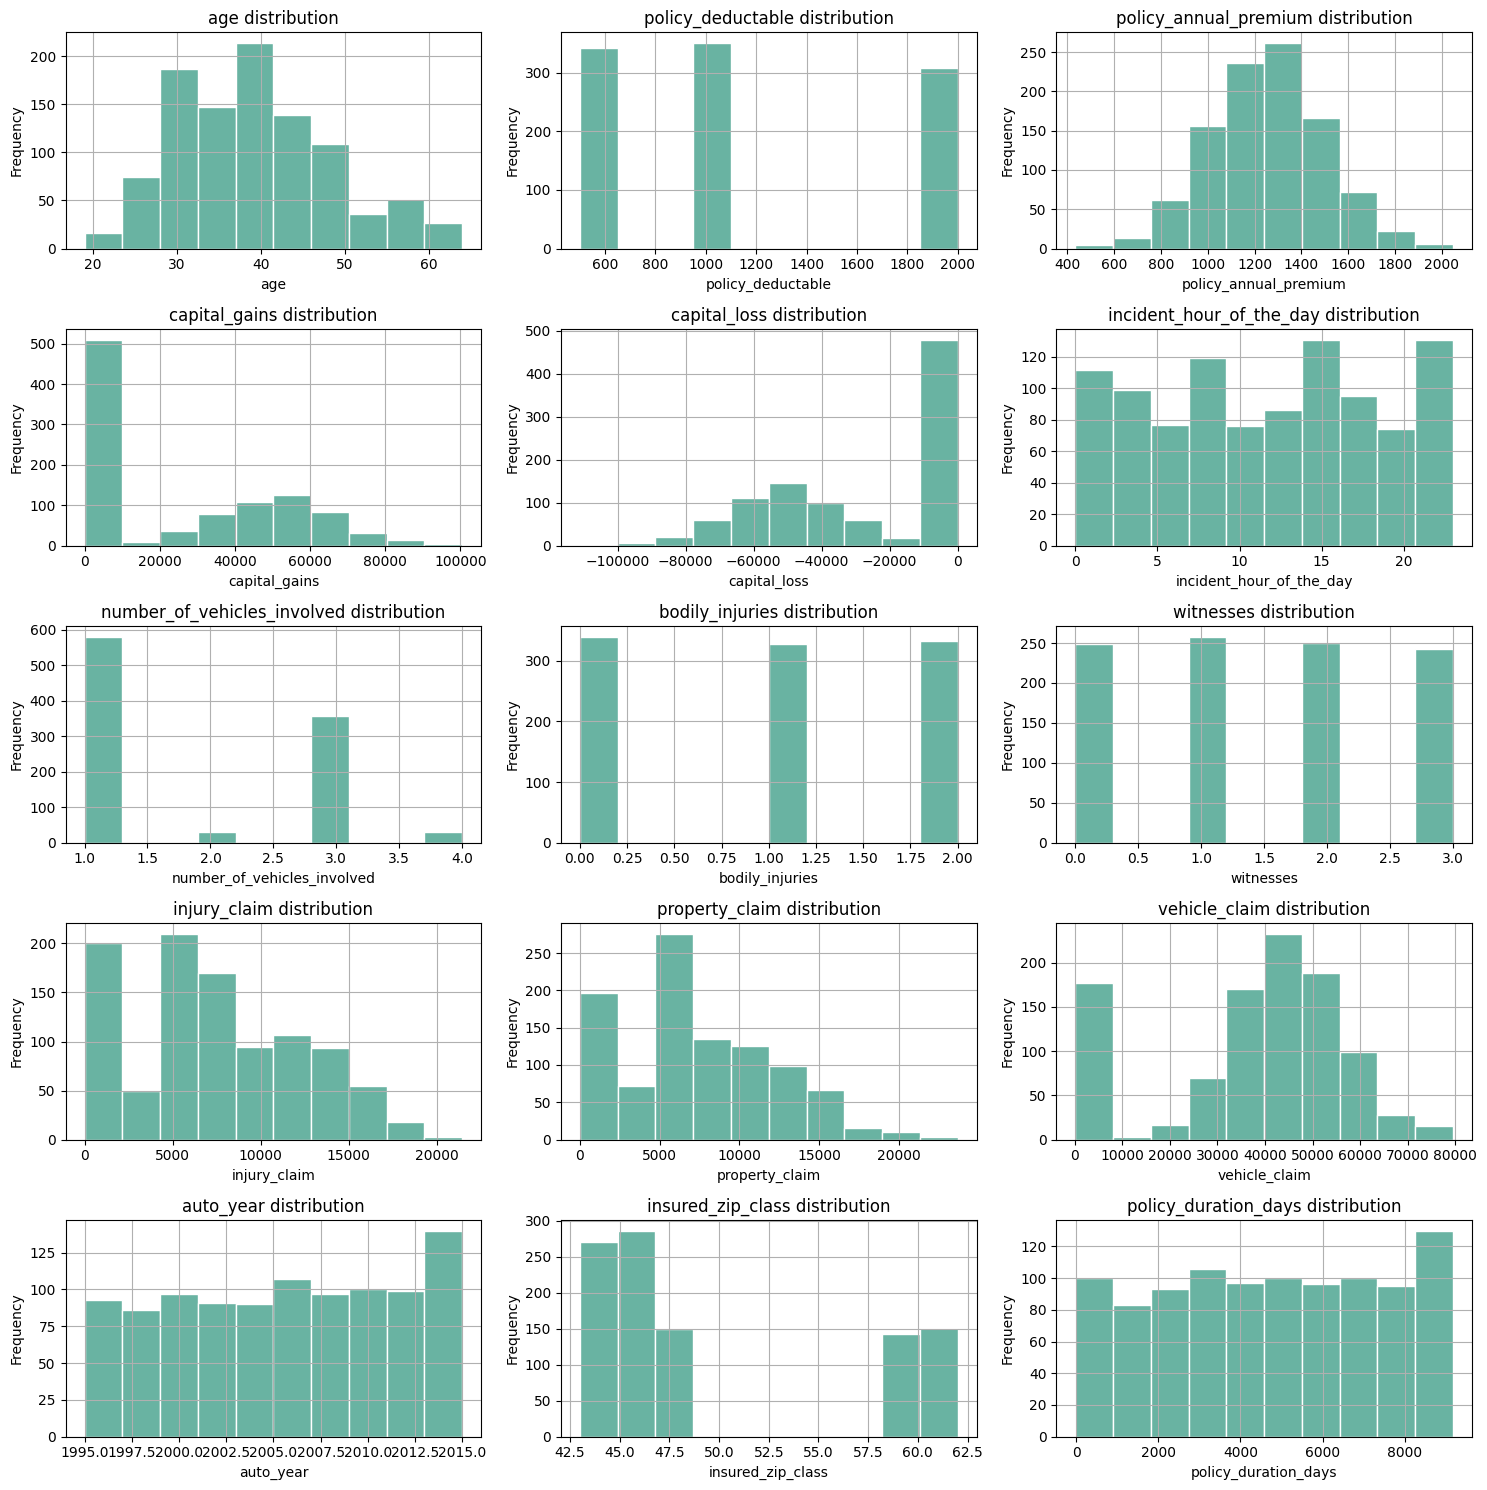

In [7]:
# Initialize a 5x3 charts
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

num_col = ['age', 'policy_deductable', 'policy_annual_premium', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day', 
           'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 
           'auto_year', 'insured_zip_class', 'policy_duration_days']
for i, column in enumerate(df[num_col]):
    
    # Add the histogram
    df[column].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )
    
    # Add title and axis label
    axes[i].set_title(f'{column} distribution') 
    axes[i].set_xlabel(column) 
    axes[i].set_ylabel('Frequency') 

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


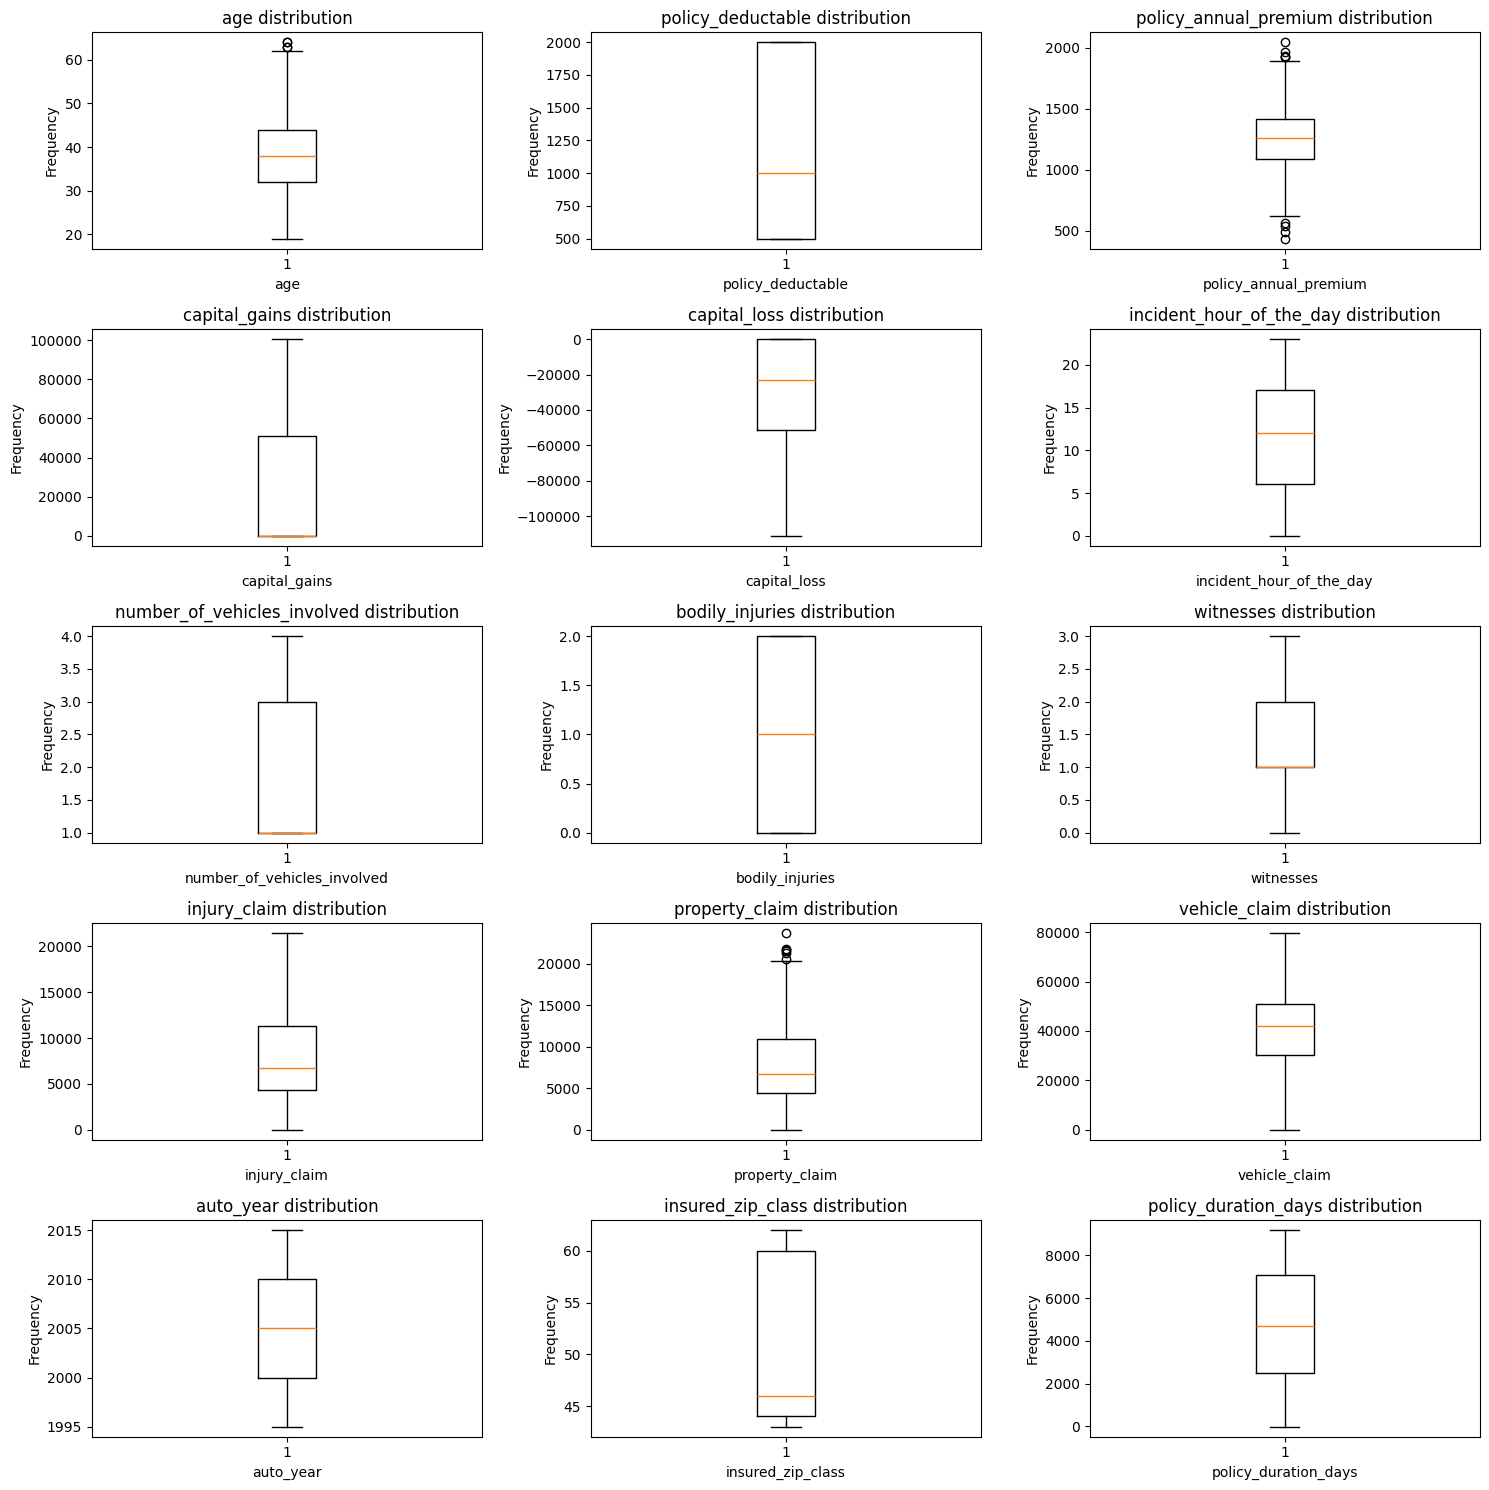

In [8]:
# Initialize a 5x3 charts
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

num_col = ['age', 'policy_deductable', 'policy_annual_premium', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day', 
           'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 
           'auto_year', 'insured_zip_class', 'policy_duration_days']
for i, column in enumerate(df[num_col]):
    axes[i].boxplot(df[column])
    # Add title and axis label
    axes[i].set_title(f'{column} distribution') 
    axes[i].set_xlabel(column) 
    axes[i].set_ylabel('Frequency') 

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [9]:
minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler() # Z-score normalization
rbst_scaler = RobustScaler()

minmax_col = ['policy_deductable', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day', 
           'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'vehicle_claim', 
           'auto_year', 'insured_zip_class', 'policy_duration_days']
rbst_col = ['age', 'property_claim']

std_col = ['policy_annual_premium']

for column in minmax_col:
    df[column] = minmax_scaler.fit_transform(df[[column]])
    
for column in rbst_col:
    df[column] = rbst_scaler.fit_transform(df[[column]])
    
for column in std_col:
    df[column] = std_scaler.fit_transform(df[[column]])
    

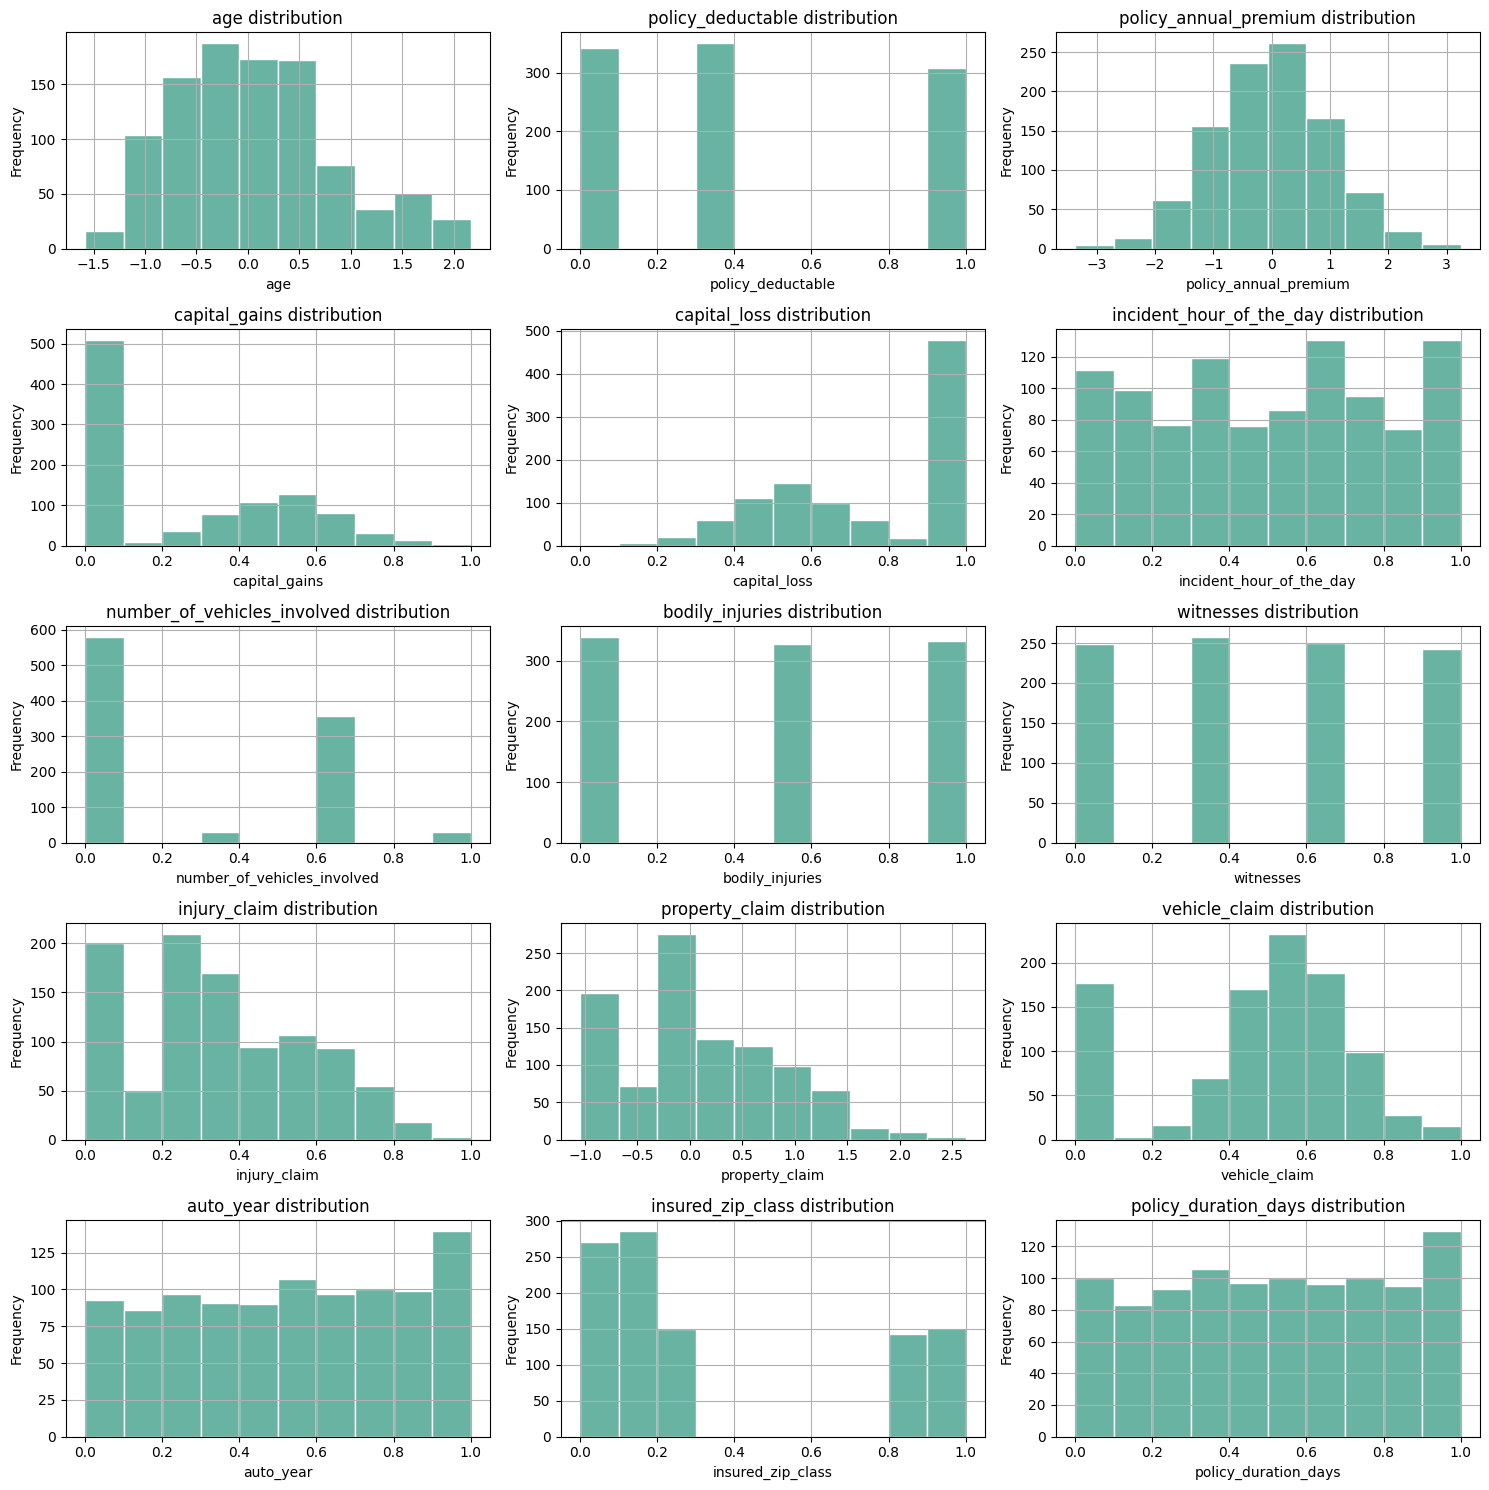

In [10]:
# Initialize a 5x3 charts
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

num_col = ['age', 'policy_deductable', 'policy_annual_premium', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day', 
           'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 
           'auto_year', 'insured_zip_class', 'policy_duration_days']
for i, column in enumerate(df[num_col]):
    
    # Add the histogram
    df[column].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )
    
    # Add title and axis label
    axes[i].set_title(f'{column} distribution') 
    axes[i].set_xlabel(column) 
    axes[i].set_ylabel('Frequency') 

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [11]:
LabelEnc = LabelEncoder()
df['fraud_reported'] = LabelEnc.fit_transform(df['fraud_reported'])
df.head()

,Unnamed: 0,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,insured_sex,insured_education_level,insured_occupation,insured_hobbies,...,police_report_available,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,insured_zip_class,policy_duration_days
0,0,0.833333,OH,250/500,0.333333,0.616705,MALE,MD,craft-repair,sleeping,...,YES,0.303497,0.973602,0.654296,Saab,92x,0.45,1,0.157895,0.013055
1,1,0.333333,IN,250/500,1.000000,-0.242521,MALE,MD,machine-op-inspct,reading,...,Unknown,0.036364,-0.927019,0.043276,Mercedes,E400,0.60,1,0.157895,0.342689
2,2,-0.750000,OH,100/300,1.000000,0.642233,FEMALE,PhD,sales,board-games,...,NO,0.358974,-0.450311,0.289722,Dodge,RAM,0.60,0,0.000000,0.576806
3,3,0.250000,IL,250/500,1.000000,0.652886,FEMALE,PhD,armed-forces,board-games,...,NO,0.295571,-0.063665,0.637187,Chevrolet,Tahoe,0.95,1,0.894737,0.980853
4,4,0.500000,IL,500/1000,0.333333,1.341980,MALE,Associate,sales,board-games,...,NO,0.060606,-0.947205,0.056359,Accura,RSX,0.70,0,0.947368,0.030026


In [12]:
df.to_csv('insurance_claims_clean_scaled.csv')